<a href="https://colab.research.google.com/github/manisharan0902-netizen/SharanTheAnalyst/blob/main/Airline_Passenger_Review_Analytics_%26_Seat_Type_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

# Load the dataset (replace 'dataset.csv' with your dataset file path)
# The original path was a local path (C:\Users\Pranathi Sandela\Downloads\archive (4)\Airlines Reviews and Rating.csv)
# This needs to be changed to a path accessible within Google Colab.
# You can upload the file directly to Colab or mount Google Drive.
# For uploaded files, a common path is './your_file_name.csv' or '/content/your_file_name.csv'
df = pd.read_csv("Airlines Reviews and Rating.csv") # Assuming the file is uploaded to the Colab session's root directory

# Get the size of the dataset
dataset_size = len(df)

# Get the number of measurements (columns) in the dataset
num_measurements = df.shape[1]

# Get the type of measurements (data types of each column)
measurement_types = df.dtypes

# Get the number of classes and their labels (for classification tasks)
# You might need to replace 'class_label' with an actual column name if performing classification
if 'class_label' in df.columns:  # Replace 'class_label' with the actual column name containing labels
    num_classes = df['class_label'].nunique()
    class_labels = df['class_label'].unique()
else:
    num_classes = None
    class_labels = None

# Print the dataset description
print("Dataset Size:", dataset_size)
print("Number of Measurements:", num_measurements)
print("Type of Measurements:")
print(measurement_types)
print("Number of Classes:", num_classes)
print("Class Labels:", class_labels)


FileNotFoundError: [Errno 2] No such file or directory: 'Airlines Reviews and Rating.csv'

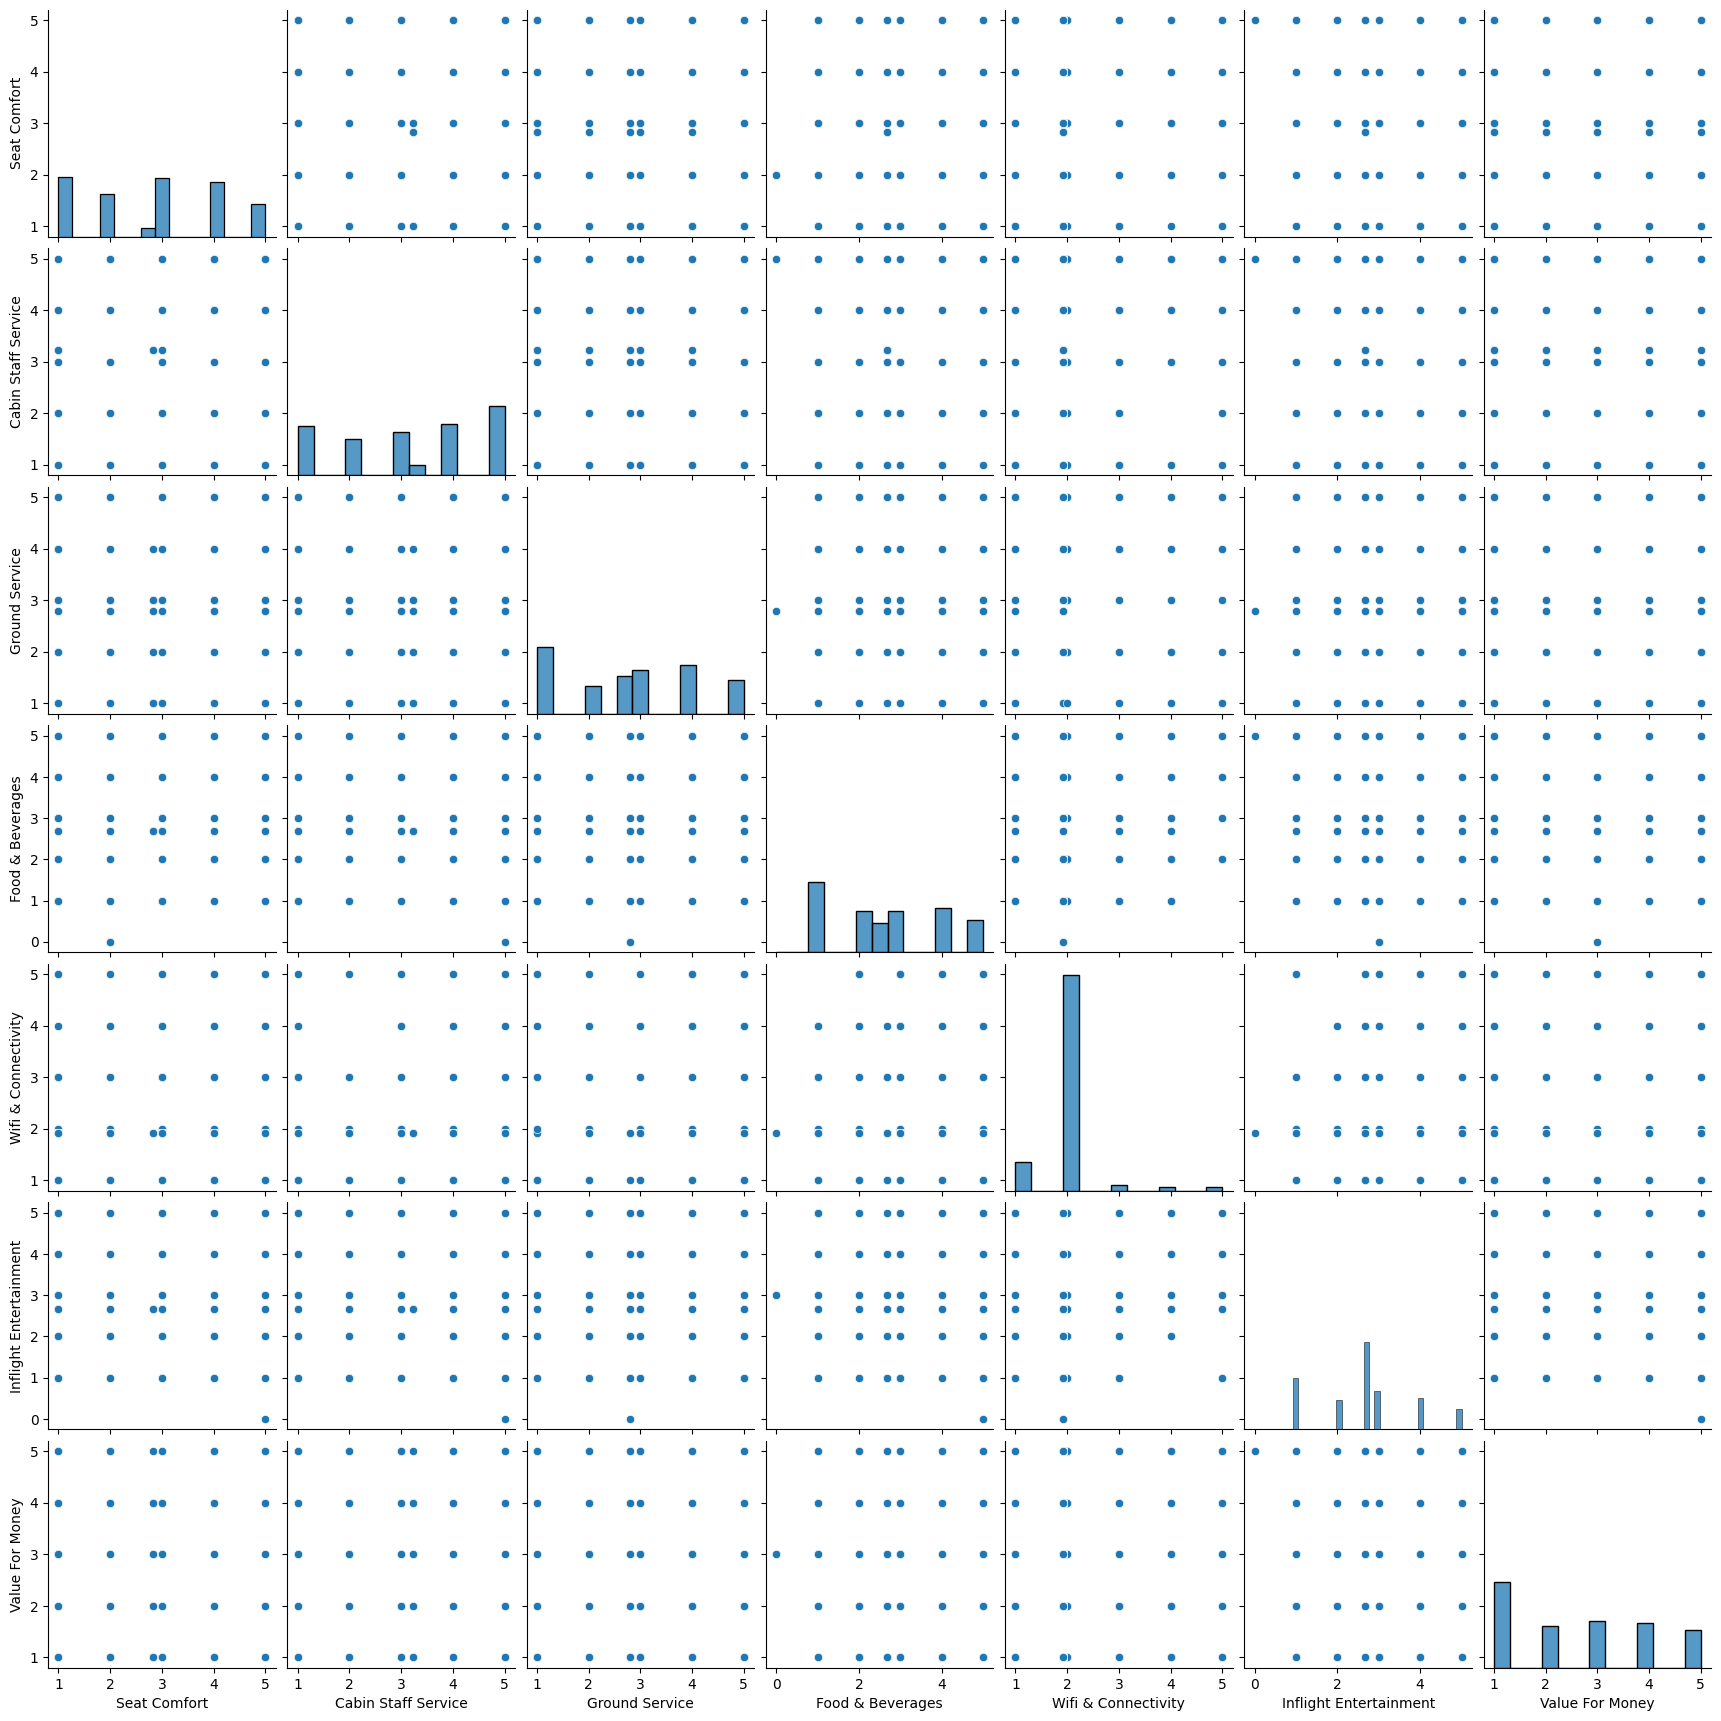

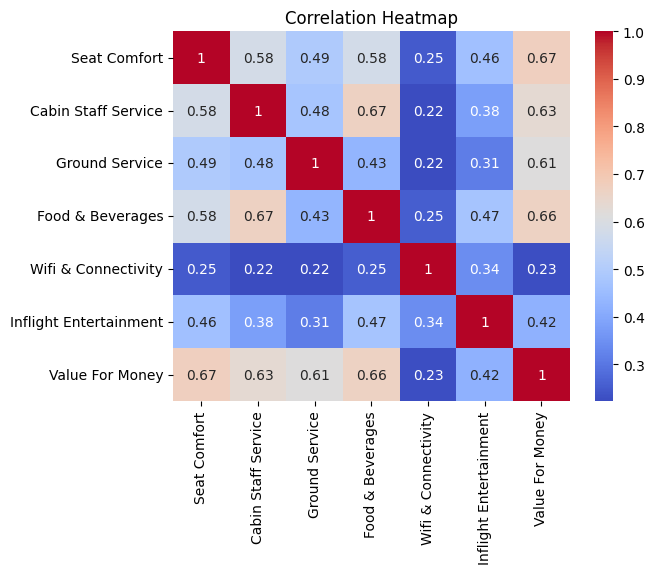

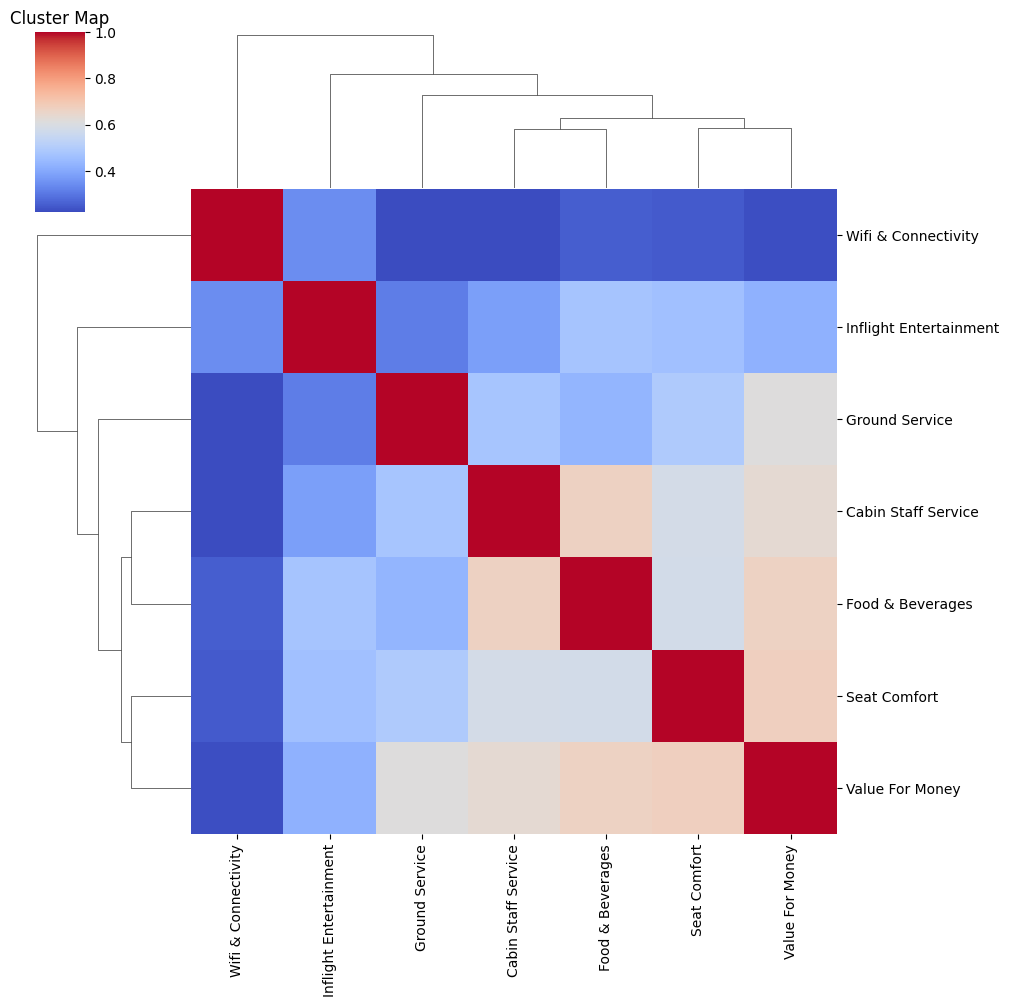

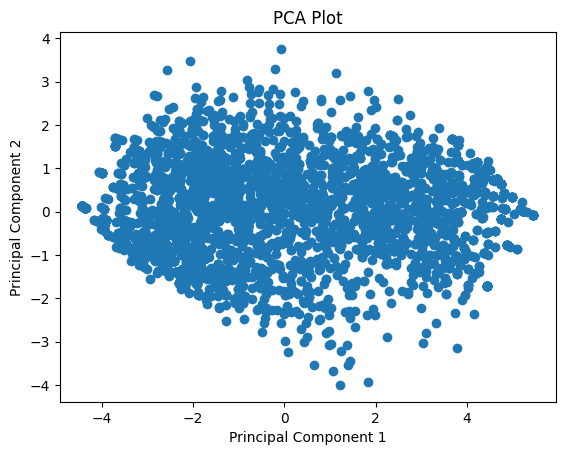

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

# Load the dataset (replace 'dataset.csv' with your dataset file path)
df = pd.read_csv("Airlines Reviews and Rating.csv")

# Drop non-numeric columns
numeric_df = df.select_dtypes(include='number')

# Impute missing values using mean imputation
imputer = SimpleImputer(strategy='mean')
numeric_df_imputed = pd.DataFrame(imputer.fit_transform(numeric_df), columns=numeric_df.columns)

# Create a scatter plot matrix
sns.pairplot(numeric_df_imputed)
plt.show()

# Calculate the correlation matrix
corr = numeric_df_imputed.corr()

# Create a heatmap of the correlation matrix
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Create a cluster map
sns.clustermap(corr, cmap='coolwarm')
plt.title('Cluster Map')
plt.show()

# Perform PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(numeric_df_imputed)

# Create a scatter plot of PCA results
plt.scatter(pca_result[:, 0], pca_result[:, 1])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Plot')
plt.show()

In [5]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.neighbors import LocalOutlierFactor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

# Load the dataset
try:
    df = pd.read_csv("Airlines Reviews and Rating.csv")
except FileNotFoundError:
    print("Error: File not found. Please check the file path.")
    exit()
except Exception as e:
    print(f"Error loading dataset: {e}")
    exit()

# Separate numerical and categorical columns
numeric_columns = df.select_dtypes(include='number').columns
categorical_columns = df.select_dtypes(include='object').columns

# Define preprocessing steps
numeric_transformer = make_pipeline(SimpleImputer(strategy='mean'), StandardScaler())
categorical_transformer = make_pipeline(SimpleImputer(strategy='most_frequent'), OneHotEncoder(handle_unknown='ignore'))

# Apply preprocessing steps individually
try:
    # Numerical preprocessing
    numeric_data = numeric_transformer.fit_transform(df[numeric_columns])

    # Categorical preprocessing
    categorical_data = categorical_transformer.fit_transform(df[categorical_columns])

    # Concatenate numerical and categorical data
    preprocessed_data = pd.concat([pd.DataFrame(numeric_data), pd.DataFrame(categorical_data)], axis=1)

    print("Preprocessing completed successfully.")
except Exception as e:
    print(f"Error during preprocessing: {e}")

Preprocessing completed successfully.


In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load your dataset
try:
    df = pd.read_csv("Airlines Reviews and Rating.csv")
except FileNotFoundError:
    print("Error: File not found. Please check the file path.")
    exit()
except Exception as e:
    print(f"Error loading dataset: {e}")
    exit()

# Check for missing values
if df.isnull().values.any():
    print("Warning: Dataset contains missing values. Please handle them appropriately.")
    # Handle missing values here, such as imputation or removal

# Separate features and target variable
X = df.drop(columns=['Seat_Types'])  # Replace 'target_column' with the name of your target variable column
y = df['Seat_Types']

# Split the dataset into training and testing sets
try:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    print("Splitting dataset into training and testing sets completed successfully.")
except Exception as e:
    print(f"Error during dataset splitting: {e}")
    exit()

# Check if any of the variables are None after splitting
if any(v is None for v in [X_train, X_test, y_train, y_test]):
    print("Error: One or more variables are None after dataset splitting.")
    exit()

# Proceed with further processing or modeling steps here

Splitting dataset into training and testing sets completed successfully.


In [7]:
# Define three different values of k
k_values = [3, 10, 30]

# Discuss the reasons for choosing each value of k
for k in k_values:
    print(f"Value of k: {k}")
    print("Reasons for choosing this value:")
    if k == 3:
        print("- Captures more local information")
        print("- Less influenced by outliers")
        print("- Can capture complex patterns in the data")
    elif k == 10:
        print("- Strikes a balance between local information and outlier reduction")
        print("- Provides a good trade-off between bias and variance")
        print("- Offers robustness against noise while capturing meaningful patterns")
    elif k == 30:
        print("- Generalizes better and more robust to noise and outliers")
        print("- Smooth decision boundary")
        print("- Better generalization to unseen data")
    print("\n")


Value of k: 3
Reasons for choosing this value:
- Captures more local information
- Less influenced by outliers
- Can capture complex patterns in the data


Value of k: 10
Reasons for choosing this value:
- Strikes a balance between local information and outlier reduction
- Provides a good trade-off between bias and variance
- Offers robustness against noise while capturing meaningful patterns


Value of k: 30
Reasons for choosing this value:
- Generalizes better and more robust to noise and outliers
- Smooth decision boundary
- Better generalization to unseen data




In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# Load your dataset
try:
    df = pd.read_csv("Airlines Reviews and Rating.csv")
except FileNotFoundError:
    print("Error: File not found. Please check the file path.")
    exit()
except Exception as e:
    print(f"Error loading dataset: {e}")
    exit()

# Handle missing values
df = df.apply(lambda x: x.fillna(x.mode()[0]) if x.dtype == "object" else x.fillna(x.mean()))

# Separate features and target variable
X = df.drop(columns=['Seat_Types'])
y = df['Seat_Types']

# Encode categorical variables
categorical_columns = X.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in categorical_columns:
    X[col] = le.fit_transform(X[col])

# Split the dataset into training and testing sets
try:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    print("Splitting dataset into training and testing sets completed successfully.")
except Exception as e:
    print(f"Error during dataset splitting: {e}")
    exit()

# Check if any of the variables are None after splitting
if any(v is None for v in [X_train, X_test, y_train, y_test]):
    print("Error: One or more variables are None after dataset splitting.")
    exit()

# Define the values of K
k_values = [3, 10, 30]

for k in k_values:
    print(f"Value of K: {k}")
    print("Reasons for choosing this value:")
    if k == 3:
        print("- Captures more local information")
        print("- Less influenced by outliers")
        print("- Can capture complex patterns in the data")
    elif k == 10:
        print("- Strikes a balance between local information and outlier reduction")
        print("- Provides a good trade-off between bias and variance")
        print("- Offers robustness against noise while capturing meaningful patterns")
    elif k == 30:
        print("- Generalizes better and more robust to noise and outliers")
        print("- Smooth decision boundary")
        print("- Better generalization to unseen data")

    # Create a KNN classifier with the current value of K
    knn = KNeighborsClassifier(n_neighbors=k)

    # Fit the classifier on the training data
    knn.fit(X_train.values, y_train)  # Convert X_train to NumPy array

    # Make predictions on the test data
    y_pred = knn.predict(X_test.values)  # Convert X_test to NumPy array

    # Calculate the accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.2f}")

    # Get the first test data point
    test_point = X_test.iloc[0]

    # 1. Calculate the distance
    distances, indices = knn.kneighbors([test_point.values])  # Convert test_point to NumPy array
    print("\n1. Calculate the distance:")
    print("Distances to the test point:", distances)

    # 2. Find the nearest neighbors
    print("\n2. Find the nearest neighbors:")
    print("Indices of nearest neighbors in the training set:", indices)

    # 3. Making predictions
    print("\n3. Making predictions:")
    predicted_label = knn.predict([test_point.values])[0]  # Convert test_point to NumPy array
    print(f"Predicted label for the test point: {predicted_label}")
    print()

Splitting dataset into training and testing sets completed successfully.
Value of K: 3
Reasons for choosing this value:
- Captures more local information
- Less influenced by outliers
- Can capture complex patterns in the data
Accuracy: 0.47

1. Calculate the distance:
Distances to the test point: [[ 5.11070882 39.14077158 61.7008914 ]]

2. Find the nearest neighbors:
Indices of nearest neighbors in the training set: [[ 569 2198 1095]]

3. Making predictions:
Predicted label for the test point: Business Class

Value of K: 10
Reasons for choosing this value:
- Strikes a balance between local information and outlier reduction
- Provides a good trade-off between bias and variance
- Offers robustness against noise while capturing meaningful patterns
Accuracy: 0.51

1. Calculate the distance:
Distances to the test point: [[  5.11070882  39.14077158  61.7008914   71.50524456  75.35914012
   86.56858174  93.16651759  97.90268932 102.97086967 105.40398474]]

2. Find the nearest neighbors:
Indi

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# Load your dataset
try:
    df = pd.read_csv("Airlines Reviews and Rating.csv")
except FileNotFoundError:
    print("Error: File not found. Please check the file path.")
    exit()
except Exception as e:
    print(f"Error loading dataset: {e}")
    exit()

# Handle missing values
df = df.apply(lambda x: x.fillna(x.mode()[0]) if x.dtype == "object" else x.fillna(x.mean()))

# Separate features and target variable
X = df.drop(columns=['Seat_Types'])
y = df['Seat_Types']

# Encode categorical variables
categorical_columns = X.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in categorical_columns:
    X[col] = le.fit_transform(X[col])

# Split the dataset into training and testing sets
try:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    print("Splitting dataset into training and testing sets completed successfully.")
except Exception as e:
    print(f"Error during dataset splitting: {e}")
    exit()

# Check if any of the variables are None after splitting
if any(v is None for v in [X_train, X_test, y_train, y_test]):
    print("Error: One or more variables are None after dataset splitting.")
    exit()

# Define the values of K
k_values = [3, 10, 30]

for k in k_values:
    print(f"Value of K: {k}")
    print("Reasons for choosing this value:")
    if k == 3:
        print("- Captures more local information")
        print("- Less influenced by outliers")
        print("- Can capture complex patterns in the data")
    elif k == 10:
        print("- Strikes a balance between local information and outlier reduction")
        print("- Provides a good trade-off between bias and variance")
        print("- Offers robustness against noise while capturing meaningful patterns")
    elif k == 30:
        print("- Generalizes better and more robust to noise and outliers")
        print("- Smooth decision boundary")
        print("- Better generalization to unseen data")

    # Create a KNN classifier with the current value of K
    knn = KNeighborsClassifier(n_neighbors=k)

    # Fit the classifier on the training data
    knn.fit(X_train.values, y_train)  # Convert X_train to NumPy array

    # Calculate training accuracy
    y_train_pred = knn.predict(X_train.values)  # Convert X_train to NumPy array
    train_accuracy = accuracy_score(y_train, y_train_pred)
    print(f"Training Accuracy: {train_accuracy:.2f}")

    # Make predictions on the test data
    y_pred = knn.predict(X_test.values)  # Convert X_test to NumPy array

    # Calculate the testing accuracy
    test_accuracy = accuracy_score(y_test, y_pred)
    print(f"Testing Accuracy: {test_accuracy:.2f}")

    # Compare training and testing accuracy
    print("Difference between Training and Testing Accuracy: {:.2f}".format(train_accuracy - test_accuracy))
    if train_accuracy > test_accuracy:
        print("The model is likely overfitting the training data.")
    else:
        print("The model is generalizing well to unseen data.")
    print()

    # Get the first test data point
    test_point = X_test.iloc[0]

Splitting dataset into training and testing sets completed successfully.
Value of K: 3
Reasons for choosing this value:
- Captures more local information
- Less influenced by outliers
- Can capture complex patterns in the data
Training Accuracy: 0.68
Testing Accuracy: 0.47
Difference between Training and Testing Accuracy: 0.20
The model is likely overfitting the training data.

Value of K: 10
Reasons for choosing this value:
- Strikes a balance between local information and outlier reduction
- Provides a good trade-off between bias and variance
- Offers robustness against noise while capturing meaningful patterns
Training Accuracy: 0.59
Testing Accuracy: 0.51
Difference between Training and Testing Accuracy: 0.08
The model is likely overfitting the training data.

Value of K: 30
Reasons for choosing this value:
- Generalizes better and more robust to noise and outliers
- Smooth decision boundary
- Better generalization to unseen data
Training Accuracy: 0.55
Testing Accuracy: 0.53
Diffe

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score
from sklearn.preprocessing import LabelEncoder # Make sure LabelEncoder is imported here

# Load your dataset
try:
    df = pd.read_csv("Airlines Reviews and Rating.csv")
except FileNotFoundError:
    print("Error: File not found. Please check the file path.")
    exit()
except Exception as e:
    print(f"Error loading dataset: {e}")
    exit()

# Handle missing values
df = df.apply(lambda x: x.fillna(x.mode()[0]) if x.dtype == "object" else x.fillna(x.mean()))

# Separate features and target variable
X = df.drop(columns=['Seat_Types'])
y = df['Seat_Types']

# Encode categorical variables
categorical_columns = X.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in categorical_columns:
    X[col] = le.fit_transform(X[col])

# Split the dataset into training and testing sets
try:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    print("Splitting dataset into training and testing sets completed successfully.")
except Exception as e:
    print(f"Error during dataset splitting: {e}")
    exit()

# Check if any of the variables are None after splitting
if any(v is None for v in [X_train, X_test, y_train, y_test]):
    print("Error: One or more variables are None after dataset splitting.")
    exit()

# Define the values of K
k_values = [3, 10, 30]

for k in k_values:
    print(f"Value of K: {k}")
    print("Reasons for choosing this value:")
    if k == 3:
        print("- Captures more local information")
        print("- Less influenced by outliers")
        print("- Can capture complex patterns in the data")
    elif k == 10:
        print("- Strikes a balance between local information and outlier reduction")
        print("- Provides a good trade-off between bias and variance")
        print("- Offers robustness against noise while capturing meaningful patterns")
    elif k == 30:
        print("- Generalizes better and more robust to noise and outliers")
        print("- Smooth decision boundary")
        print("- Better generalization to unseen data")

    # Create a KNN classifier with the current value of K
    knn = KNeighborsClassifier(n_neighbors=k)

    # Fit the classifier on the training data
    knn.fit(X_train.values, y_train)  # Convert X_train to NumPy array

    # Make predictions on the test data
    y_pred = knn.predict(X_test.values)  # Convert X_test to NumPy array

    # Calculate the testing accuracy
    test_accuracy = accuracy_score(y_test, y_pred)
    print(f"Testing Accuracy: {test_accuracy:.2f}")

    # Create a confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(conf_matrix)

    # Calculate recall and precision scores
    recall = recall_score(y_test, y_pred, average='weighted')
    try:
        precision = precision_score(y_test, y_pred, average='weighted', zero_division='raise')
    except ValueError:
        precision = 0.0
        print("Precision score is undefined due to division by zero. Setting it to 0.0.")
    else:
        print(f"Precision Score: {precision:.2f}")

    print(f"Recall Score: {recall:.2f}")

    # Discuss prediction results
    print("\nDiscussion:")
    if test_accuracy > 0.9:
        print("The model has high accuracy and low misclassification error.")
    elif test_accuracy > 0.8:
        print("The model has reasonably good accuracy, but there is room for improvement.")
    else:
        print("The model has low accuracy and a high misclassification error.")

    print(f"The recall score of {recall:.2f} indicates the model's ability to correctly identify positive instances.")
    print(f"The precision score of {precision:.2f} indicates the model's ability to avoid false positives.")

    print()

    # Get the first test data point
    test_point = X_test.iloc[0]

Splitting dataset into training and testing sets completed successfully.
Value of K: 3
Reasons for choosing this value:
- Captures more local information
- Less influenced by outliers
- Can capture complex patterns in the data
Testing Accuracy: 0.47
Confusion Matrix:
[[107 126   4   1]
 [117 201   5  11]
 [ 18  13   0   2]
 [ 28  21   0   4]]
Precision score is undefined due to division by zero. Setting it to 0.0.
Recall Score: 0.47

Discussion:
The model has low accuracy and a high misclassification error.
The recall score of 0.47 indicates the model's ability to correctly identify positive instances.
The precision score of 0.00 indicates the model's ability to avoid false positives.

Value of K: 10
Reasons for choosing this value:
- Strikes a balance between local information and outlier reduction
- Provides a good trade-off between bias and variance
- Offers robustness against noise while capturing meaningful patterns
Testing Accuracy: 0.51
Confusion Matrix:
[[ 88 149   1   0]
 [ 78